In [64]:
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [66]:
print(f"""X_train shape: {X_train.shape}
y_train shape: {y_train.shape}
X_test shape: {X_test.shape}
y_test shape: {y_test.shape}
""")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)



np.uint8(9)

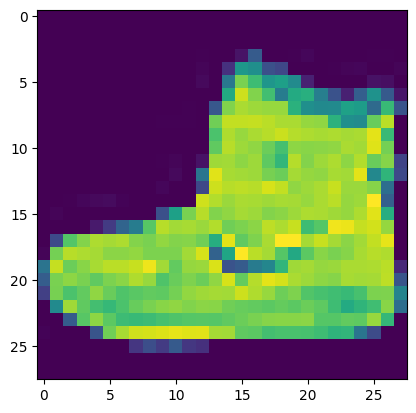

In [67]:
plt.imshow(X_train[0])
# print(X_train[0])
y_train[0]

In [68]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print(class_names[y_train[0]])

Ankle boot


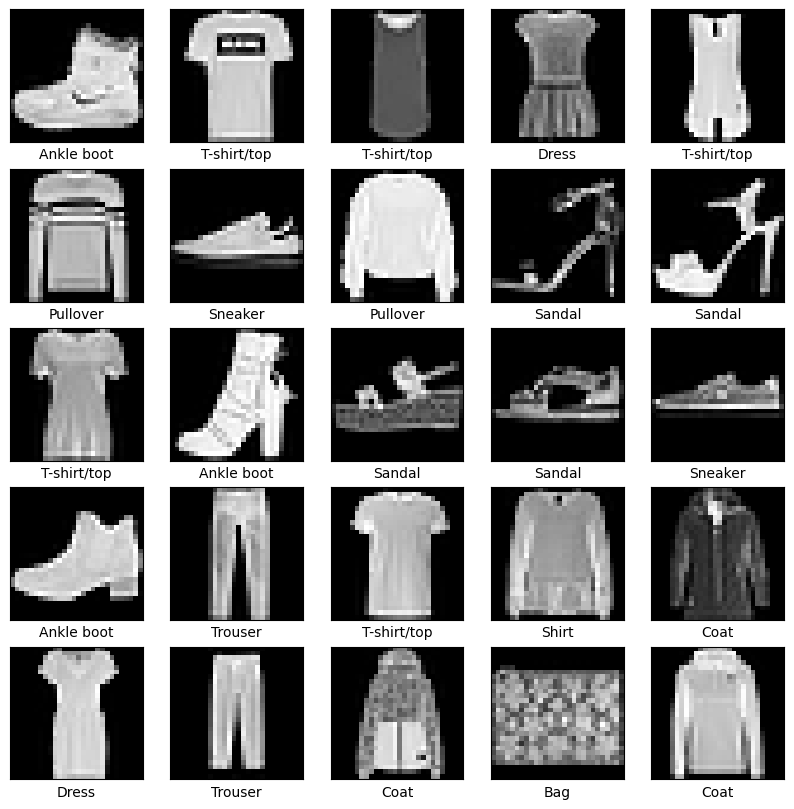

In [69]:
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap='gray')
    plt.xlabel(class_names[y_train[i]])
plt.show()

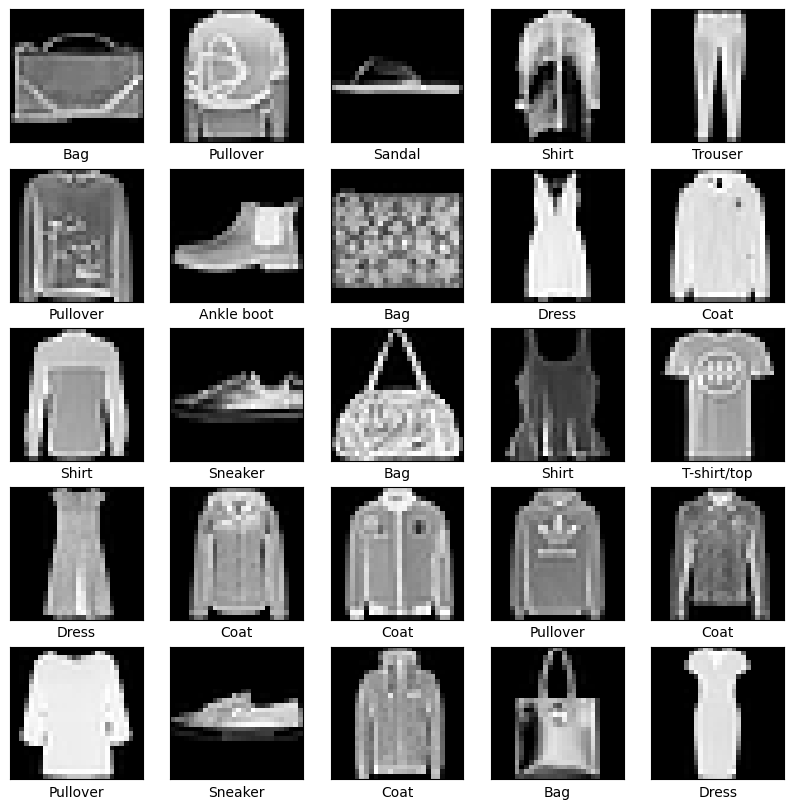

In [70]:
plt.figure(figsize=(10, 10))

# pick 25 random indices
random_indices = np.random.randint(0, len(X_train), 25)

for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[idx], cmap='gray')
    plt.xlabel(class_names[y_train[idx]])

plt.show()

In [71]:
## Let is normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [72]:
X_train.shape

(60000, 28, 28)

In [73]:
## Now we need to reshpae the data because CNN want height weight and channel
X_train = X_train.reshape(-1, 28,28,1)
X_test = X_test.reshape(-1, 28,28,1)

In [74]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras import Input



In [75]:
model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [76]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [77]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8306 - loss: 0.4702 - val_accuracy: 0.8787 - val_loss: 0.3401
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8849 - loss: 0.3150 - val_accuracy: 0.8947 - val_loss: 0.2969
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9024 - loss: 0.2665 - val_accuracy: 0.9001 - val_loss: 0.2752
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9151 - loss: 0.2327 - val_accuracy: 0.9054 - val_loss: 0.2580
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9233 - loss: 0.2045 - val_accuracy: 0.9045 - val_loss: 0.2612
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9335 - loss: 0.1797 - val_accuracy: 0.9133 - val_loss: 0.2494
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9399 - loss: 0.1604 - val_accuracy: 0.9080 - val_loss: 0.2724
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9471 - loss: 0.1412 -

In [78]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"""Test Accuracy: {accuracy*100:.2f}%
Loss: {loss:.2f}""")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9085 - loss: 0.2901
Test Accuracy: 90.85%
Loss: 0.29


In [79]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [80]:
print(y_pred)

[[4.5978320e-13 1.2095526e-12 3.5001699e-16 ... 3.2019948e-06
  9.0427062e-11 9.9999678e-01]
 [1.9967569e-08 3.7166077e-18 1.0000000e+00 ... 1.7898731e-17
  1.0654736e-15 7.2356146e-15]
 [4.3998052e-14 1.0000000e+00 1.1401951e-14 ... 4.0013008e-30
  1.7922748e-13 2.1855243e-24]
 ...
 [1.2682508e-11 2.0212668e-14 2.1414972e-11 ... 2.0774410e-14
  1.0000000e+00 8.0444265e-16]
 [2.2058879e-15 1.0000000e+00 5.5952608e-15 ... 1.7775875e-21
  8.5126388e-15 1.4502949e-19]
 [1.3895838e-04 5.5695145e-06 2.3701541e-06 ... 3.3844456e-02
  3.2843921e-02 1.7180773e-05]]


In [81]:
y_pred = np.argmax(y_pred, axis=1)

In [82]:
y_pred[0]

np.int64(9)

In [83]:
print("Predicted:", class_names[y_pred[0]])
print("Actual:", class_names[y_test[0]])


Predicted: Ankle boot
Actual: Ankle boot


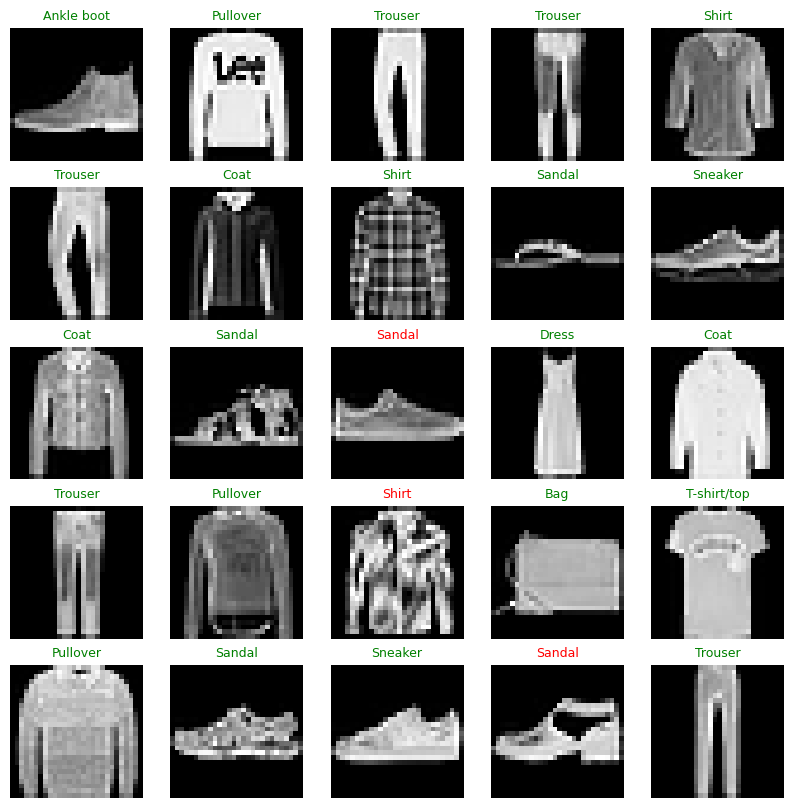

In [84]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    color = "green" if y_pred[i] == y_test[i] else "red"

    plt.title(f"{class_names[y_pred[i]]}", color=color, fontsize=9)
    plt.axis('off')

plt.show()

In [85]:
from sklearn.metrics import confusion_matrix, classification_report

In [86]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[832   0  14  14   8   1 122   0   9   0]
 [  3 977   0  12   3   0   3   0   2   0]
 [ 10   0 842   6  43   1  97   0   1   0]
 [ 15   3  10 899  39   0  29   0   5   0]
 [  0   0  45  19 863   0  69   0   4   0]
 [  0   0   0   0   0 979   0  12   0   9]
 [ 88   0  47  22  59   0 778   0   6   0]
 [  0   0   0   0   0  14   0 964   0  22]
 [  3   0   1   4   2   1   3   4 982   0]
 [  1   0   0   0   0   3   0  27   0 969]]


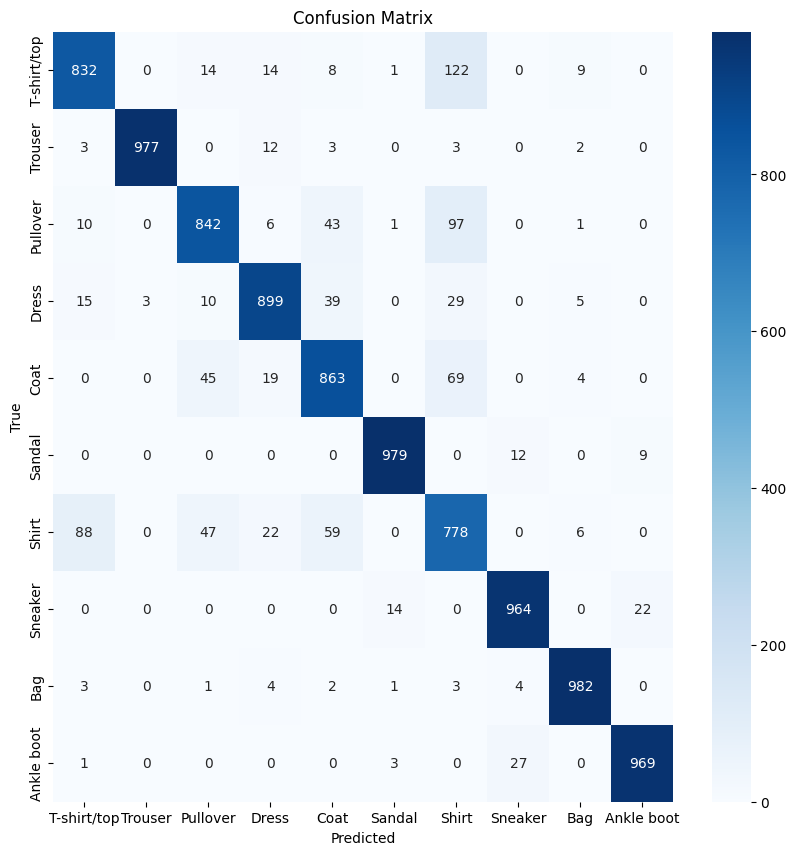

In [87]:
plt.figure(figsize=(10,10))

sns.heatmap(data=cm, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names, annot=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

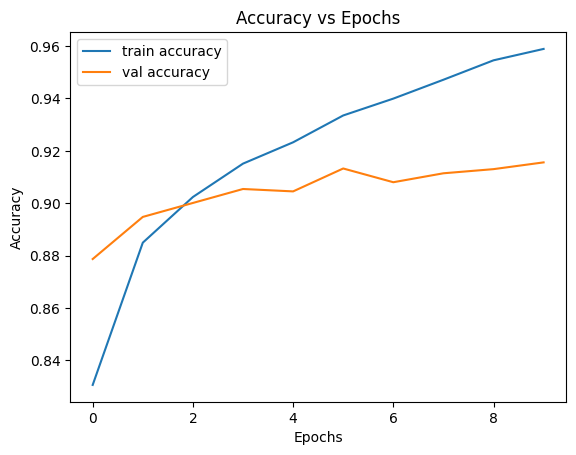

In [88]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

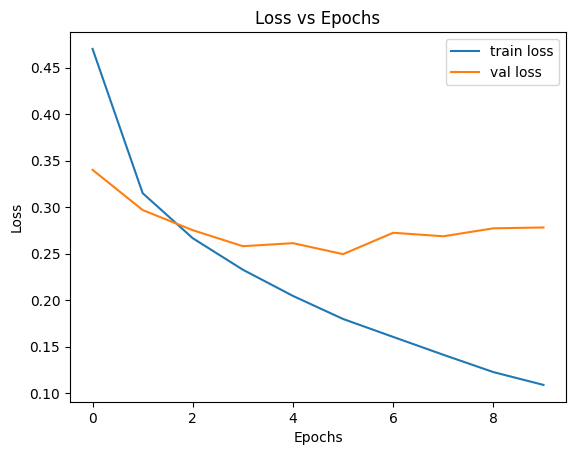

In [89]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()